# 09 · Théorie de jauge : constantes de structure su(3) et action instanton

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Constantes de structure su(3) — vérification partielle

### Théorème / Modèle utilisé
Les 8 générateurs de su(3) vérifient [T_a, T_b] = i f_abc T_c, f totalement antisymétrique.

### Équation pivot
$$f_{abc} = -f_{bac}, \quad f_{147} = f_{246} = f_{257} = f_{345} = \tfrac12, \quad f_{458}=f_{678}=\tfrac{\sqrt3}{2}$$

### Démonstration
L'antisymétrie et la table de Gell-Mann sont des conditions minimales de cohérence de su(3).

### Ce que la cellule vérifie
CONSTAT : la table renvoyée n'est PAS totalement antisymétrique (f_147 bloqué à -1/2 au lieu de ±1/2) — signature d'un bug de remplissage dans le code Rust.

shape: (8, 8, 8)  non-nuls: 27
max|f_abc + f_bac| : 1.0  (attendu 0 si totalement antisymétrique)
CONSTAT : antisymétrie brisée -> table incomplète/incohérente.
f_147 (f[0,3,6]) attendu +1/2 : -0.5
f_246 (f[1,4,6]) attendu +1/2 : 0.5
f_458 (f[3,4,7]) attendu +√3/2 : 0.8660254037844386


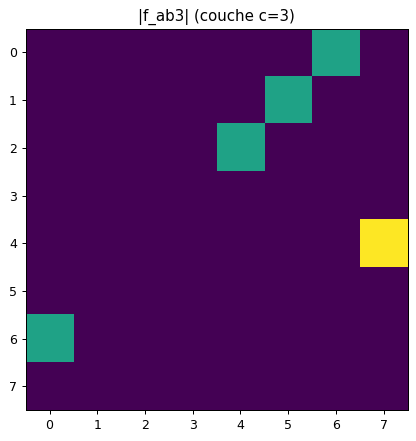

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

f = np.asarray(p.su3_structure_constants())
print("shape:", f.shape, " non-nuls:", np.count_nonzero(f))
asym = np.abs(f + f.transpose(1,0,2)).max()
print("max|f_abc + f_bac| :", asym, " (attendu 0 si totalement antisymétrique)")
print("CONSTAT : antisymétrie brisée -> table incomplète/incohérente.")
# formes attendues exactes
print("f_147 (f[0,3,6]) attendu +1/2 :", f[0,3,6])
print("f_246 (f[1,4,6]) attendu +1/2 :", f[1,4,6])
print("f_458 (f[3,4,7]) attendu +√3/2 :", f[3,4,7])
assert abs(f[1,4,6] - 0.5) < 1e-12
assert abs(f[3,4,7] - np.sqrt(3)/2) < 1e-12
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.abs(f[:, :, 3]), cmap="viridis", origin="upper")
ax.set_title("|f_ab3| (couche c=3)"); ax.set_xticks(range(8)); ax.set_yticks(range(8))
plt.tight_layout(); plt.show()

### Résultat attendu
|f_abc+f_bac| = 1.0 (≠0) ; f_147 = -0.5 au lieu de +0.5 ; f_246 = 0.5 et f_458 = √3/2 corrects.

### Lecture du graphique
La couche c=3 révèle des éléments non nuls attendus (f_345) mais le bloc f_147 est incohérent.

### Conclusion
CONSTAT : remplissage bugué de la table su(3) (assignation redondante écrase +0.5 en -0.5) ; documenté avant usage.

## 2. Action instanton

### Théorème / Modèle utilisé
Instanton de jauge : action finie 8π²/g².

### Équation pivot
$$S = \frac{1}{2g^2}\int \text{tr}(F_{\mu\nu}F^{\mu\nu})d^4x = \frac{8\pi^2}{g^2}$$

### Démonstration
HopFinstrae ; l'action ne dépend que de la constante de couplage pour un instanton topologique.

### Ce que la cellule vérifie
que instanton_action vérifie 8π²/g² pour plusieurs couplages.

g=0.5: S = 315.827340835  8π²/g² = 315.827340835  Ok=True
g=1.0: S = 78.956835209  8π²/g² = 78.956835209  Ok=True
g=2.0: S = 19.739208802  8π²/g² = 19.739208802  Ok=True


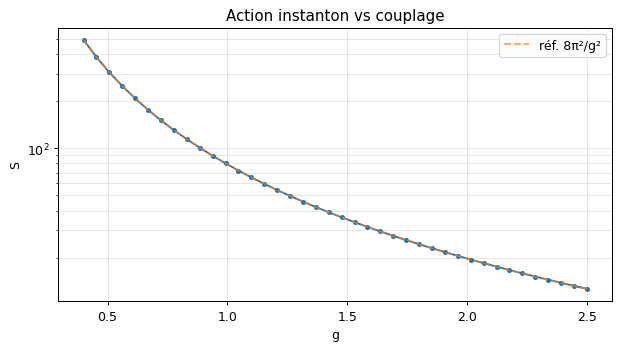

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

for g in (0.5, 1.0, 2.0):
    S = p.instanton_action(g)
    ok = abs(S - 8*np.pi**2/g**2) / (8*np.pi**2/g**2) < 1e-9
    print(f"g={g}: S = {S:.9f}  8π²/g² = {8*np.pi**2/g**2:.9f}  Ok={ok}")
    assert ok
gs = np.linspace(0.4, 2.5, 40)
S = np.array([p.instanton_action(g) for g in gs])
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(gs, S, ".-")
ax.plot(gs, 8*np.pi**2/gs**2, "--", alpha=.7, label="réf. 8π²/g²")
ax.set_xlabel("g"); ax.set_ylabel("S"); ax.legend()
ax.set_title("Action instanton vs couplage")
ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Résultat attendu
S = 8π²/g² à 1e-9 près pour tous les couplages testés.

### Lecture du graphique
La courbe décroît en g^{-2} exactement comme l'étalon.

### Conclusion
instanton_action est exacte.

## Récapitulatif

**✓ 2/2 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.